In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization and Saving
import optuna
import joblib
import warnings

# Settings
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("✅ Libraries imported.")

✅ Libraries imported.


In [6]:
# --- CONFIGURATION ---
TARGET_COLUMN = 'families'  # <--- CHANGE THIS for different notebooks
INPUT_RAW_FILE = '../../../../data/typhoon_impact_with_extreme_weather.csv'

# 1. Load Data
try:
    print(f"🎯 ANALYSIS TARGET: {TARGET_COLUMN}")
    df = pd.read_csv(INPUT_RAW_FILE)
    
    # 2. Standardize Column Names
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('/', '_')
    
    # 3. Rename columns (Adjust if your raw file is different)
    rename_map = {
        'typhoon': 'typhoon_name',
        'wind_speed': 'max_sustained_wind_kph',
        'rainfall': 'max_24hr_rainfall_mm',
        'pressure': 'min_pressure_hpa',
        'storm_rainfall': 'total_storm_rainfall_mm'
    }
    df.rename(columns=rename_map, inplace=True)

    # 4. Clean Target Column (Handle commas and NaNs)
    if TARGET_COLUMN in df.columns:
        if df[TARGET_COLUMN].dtype == 'object':
            df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.replace(',', '')
        df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').fillna(0)
    else:
        raise ValueError(f"Target '{TARGET_COLUMN}' not found in dataset.")

    # 5. FILTER: Keep only rows where Target > 0 (Remove 0s)
    df_clean = df[df[TARGET_COLUMN] > 0].copy()
    
    # 6. Handle Missing Weather Data (Fill with Median)
    weather_cols = ['max_sustained_wind_kph', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa']
    for col in weather_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    print(f"✅ Data Loaded & Cleaned.")
    print(f"   Original Rows: {len(df)}")
    print(f"   Training Rows (Target > 0): {len(df_clean)}")
    print(f"   Rows Removed: {len(df) - len(df_clean)}")

except FileNotFoundError:
    print(f"❌ Error: '{INPUT_RAW_FILE}' not found.")

🎯 ANALYSIS TARGET: families
✅ Data Loaded & Cleaned.
   Original Rows: 1776
   Training Rows (Target > 0): 1569
   Rows Removed: 207


In [14]:
# --- DATA EXPLORATION ---
print(f"📊 DATASET SUMMARY (Filtered Data for '{TARGET_COLUMN}')")
print(f"   Total Rows: {df_clean.shape[0]}")
print(f"   Total Columns: {df_clean.shape[1]}")
print("-" * 50)

print("\n--- ℹ️ Dataset Information (Data Types) ---")
df_clean.info()

print("\n--- 📉 Summary Statistics (Check for outliers) ---")
# .T makes it easier to read if you have many columns
print(df_clean.describe().T)

print("\n--- ❓ Missing Values Check ---")
print(df_clean.isnull().sum())

print("-" * 50)
print("--- 👀 Preview of First 5 Rows ---")
df_clean.head(5)

📊 DATASET SUMMARY (Filtered Data for 'families')
   Total Rows: 1569
   Total Columns: 30
--------------------------------------------------

--- ℹ️ Dataset Information (Data Types) ---
<class 'pandas.core.frame.DataFrame'>
Index: 1569 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   typhoon_name             1569 non-null   object 
 1   year                     1569 non-null   int64  
 2   region                   1569 non-null   int64  
 3   province                 1569 non-null   object 
 4   city_municipality        1569 non-null   object 
 5   families                 1569 non-null   int64  
 6   person                   1569 non-null   int64  
 7   brgy                     1569 non-null   int64  
 8   dead                     1569 non-null   int64  
 9   injured_ill              1569 non-null   int64  
 10  missing                  1569 non-null   int64  
 11  total

,typhoon_name,year,region,province,city_municipality,families,person,brgy,dead,injured_ill,...,par_end,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [7]:
# Define Features (Duration and Typhoon Type removed)
input_features = [
    'max_sustained_wind_kph',
    'max_24hr_rainfall_mm',
    'total_storm_rainfall_mm',
    'min_pressure_hpa'
]

# Select X and y
X = df_clean[input_features]
y = df_clean[TARGET_COLUMN]

# Split Data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data Split Complete.")
print(f"   Training Samples: {X_train_raw.shape[0]}")
print(f"   Testing Samples:  {X_test_raw.shape[0]}")

✅ Data Split Complete.
   Training Samples: 1255
   Testing Samples:  314


In [8]:
# Initialize Scaler
scaler = StandardScaler()

# Fit on Train, Transform both Train and Test
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("✅ Features Scaled.")
print(f"   Train Shape: {X_train.shape}")
print(f"   Test Shape:  {X_test.shape}")

✅ Features Scaled.
   Train Shape: (1255, 4)
   Test Shape:  (314, 4)


In [9]:
# Initialize and Train
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)

# Evaluate Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"📊 BASELINE MODEL RESULTS:")
print(f"   R2 Score: {base_r2:.4f}")
print(f"   RMSE:     {base_rmse:,.2f}")

📊 BASELINE MODEL RESULTS:
   R2 Score: 0.0005
   RMSE:     4,312.34


In [10]:
def objective(trial):
    # Suggest alpha (regularization strength)
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    
    model = Ridge(alpha=alpha)
    
    # Cross Validation (3-fold if possible, else 2-fold)
    cv_folds = 3 if len(X_train) > 10 else 2
    
    # We optimize for Negative MSE (closer to 0 is better)
    score = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
    return score.mean()

# Run Optimization
print("⏳ Starting Optuna Tuning...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_alpha = study.best_params['alpha']
print(f"✅ Tuning Complete. Best Alpha: {best_alpha:.4f}")

⏳ Starting Optuna Tuning...
✅ Tuning Complete. Best Alpha: 99.4577


In [11]:
# Initialize Ridge with Best Alpha
final_model = Ridge(alpha=best_alpha)

# Train on full training data
final_model.fit(X_train, y_train)

print("✅ Final Tuned Model Trained.")

✅ Final Tuned Model Trained.


🏆 FINAL PERFORMANCE (FAMILIES)
   R2 Score: 0.0020
   RMSE:     4,309.07
   MAE:      1,799.95


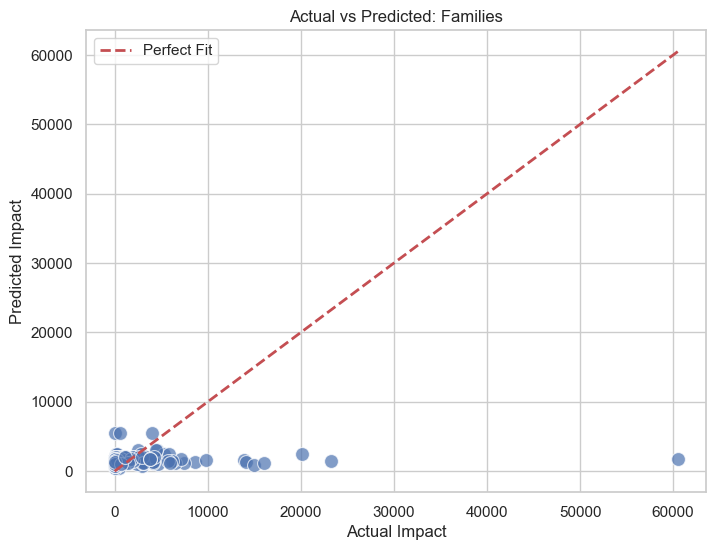

In [12]:
# Predict on Test Set
y_pred_final = np.maximum(final_model.predict(X_test), 0)

# Calculate Metrics
r2 = r2_score(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)

print(f"🏆 FINAL PERFORMANCE ({TARGET_COLUMN.upper()})")
print(f"   R2 Score: {r2:.4f}")
print(f"   RMSE:     {rmse:,.2f}")
print(f"   MAE:      {mae:,.2f}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.7, s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title(f'Actual vs Predicted: {TARGET_COLUMN.capitalize()}')
plt.xlabel('Actual Impact')
plt.ylabel('Predicted Impact')
plt.legend()
plt.show()

In [ ]:
# Output Filenames
OUTPUT_MODEL_FILE = f'model_{TARGET_COLUMN}.joblib'
OUTPUT_RESULTS_FILE = f'results_lr_{TARGET_COLUMN}.csv'

# 1. Create Summary DataFrame
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_final,
    'Target': TARGET_COLUMN
})

# 2. Save Results
results_df.to_csv(OUTPUT_RESULTS_FILE, index=False)
print(f"✅ Results saved to: {OUTPUT_RESULTS_FILE}")

# # 3. Save Model Pipeline (Model + Scaler + Feature Names)
# pipeline = {
#     'model': final_model,
#     'scaler': scaler,
#     'features': input_features,
#     'target': TARGET_COLUMN,
#     'best_params': {'alpha': best_alpha}
# }

# joblib.dump(pipeline, OUTPUT_MODEL_FILE)
# print(f"✅ Model saved to: {OUTPUT_MODEL_FILE}")

✅ Results saved to: results_lr_families.csv
✅ Model saved to: model_families.joblib
